### Ajuste hiperparámetros usando TreeDecisionClassifier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import warnings
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut
warnings.simplefilter(action='ignore', category=FutureWarning)

In [14]:
#Función que recibe un dataset y realiza la validación one leave out 
# para devolver los parámetros óptimos del modelo TreeDecisionClassifier
# Parámtros a optimizar:
# - Número máximo de hojas del árbol
# - Profundidad máxima del árbol
# - Número mínimo de ejemplos para hacer unaa partición
# Se utilizará la métrica de precisión para evaluar el rendimiento del modelo



def preprocesado(df, label='Label'):
    # Conversión de las variables categóricas a numéricas
    df.replace({
        "Age": {"young": 0, "pre-presbyopic": 1, "presbyopic": 2},
        "Prescription": {"myope": 0, "hypermetrope": 1},
        "Astigmatic": {"no": 0, "yes": 1},
        "TearRate": {"reduced": 0, "normal": 1},
        "Label": {"no lenses": 0, "soft": 1, "hard": 2}
    }, inplace=True)
    
    # Separación de las características (X) y la variable objetivo (y)
    X = df.drop(columns=[label])
    #Converisón a variables binarias (one hot encoding)
    X = pd.get_dummies(X, columns=X.columns)

    y = df[label]
    print("Características (X):")
    print(X.head())
    return X.values, y.values

def optimizar_arbol_decision(dataset, label='Label'):

    X,y = preprocesado(dataset, label=label)
    # Definir los rangos de los parámetros a optimizar
    max_leaf_nodes_range = [2, 3, 4, 5, 6, 8, 10]
    max_depth_range = [1, 2, 3, 4, 5]
    min_samples_split_range = [2, 3, 4, 5, 6]

    results = []

    # Iterar sobre todas las combinaciones de parámetros
    for max_leaf_nodes in max_leaf_nodes_range:
        for max_depth in max_depth_range:
            for min_samples_split in min_samples_split_range:
                # Crear el modelo con los parámetros actuales
                model = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=max_leaf_nodes,
                                               max_depth=max_depth,
                                               min_samples_split=min_samples_split)

                # Validación one leave out
                loo = LeaveOneOut()
                accuracies = []

                for train_index, test_index in loo.split(X):
                    X_train, X_test = X[train_index], X[test_index]
                    y_train, y_test = y[train_index], y[test_index]

                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    acc = accuracy_score(y_test, y_pred)
                    accuracies.append(acc)

                # Calcular la precisión promedio para esta combinación de parámetros
                avg_precision = np.mean(accuracies)

                results.append({
                    'max_leaf_nodes': max_leaf_nodes,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'precision': avg_precision
                })

    return results



In [15]:
df_train = pd.read_csv('data/lenses.csv')

#plt.figure(figsize=(12,6))
#sns.countplot(x='Label', data=df_train, hue="Label")

X,y = preprocesado(df_train)
print(X[:5])
print(y[:5])

Características (X):
   Age_0  Age_1  Age_2  Prescription_0  Prescription_1  Astigmatic_0  \
0   True  False  False            True           False          True   
1   True  False  False            True           False          True   
2   True  False  False            True           False         False   
3   True  False  False            True           False         False   
4   True  False  False           False            True          True   

   Astigmatic_1  TearRate_0  TearRate_1  
0         False        True       False  
1         False       False        True  
2          True        True       False  
3          True       False        True  
4         False        True       False  
[[ True False False  True False  True False  True False]
 [ True False False  True False  True False False  True]
 [ True False False  True False False  True  True False]
 [ True False False  True False False  True False  True]
 [ True False False False  True  True False  True False]]
[0 1 0 2

In [4]:
resultados = optimizar_arbol_decision(df_train)

In [5]:
#longitud de resultados
len(resultados)
#ordenar resultados por precisión
resultados_ordenados = sorted(resultados, key=lambda x: x['precision'], reverse=True)
#imprimir los mejores resultados
print(f"Mejores resultados: (resultados totales = {len(resultados_ordenados)})")
for resultado in resultados_ordenados[:69]:
    print(f"Índice: {resultados_ordenados.index(resultado)}, Parámetros: max_leaf_nodes={resultado['max_leaf_nodes']}, max_depth={resultado['max_depth']}, min_samples_split={resultado['min_samples_split']}, Precisión: {resultado['precision']:.4f}")

Mejores resultados: (resultados totales = 175)
Índice: 0, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=2, Precisión: 0.8750
Índice: 1, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=3, Precisión: 0.8750
Índice: 2, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=4, Precisión: 0.8750
Índice: 3, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=5, Precisión: 0.8750
Índice: 4, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=6, Precisión: 0.8750
Índice: 5, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=2, Precisión: 0.8750
Índice: 6, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=3, Precisión: 0.8750
Índice: 7, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=4, Precisión: 0.8750
Índice: 8, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=5, Precisión: 0.8750
Índice: 9, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=6, Precisión: 0.8750
Índice: 10, Parámetros:

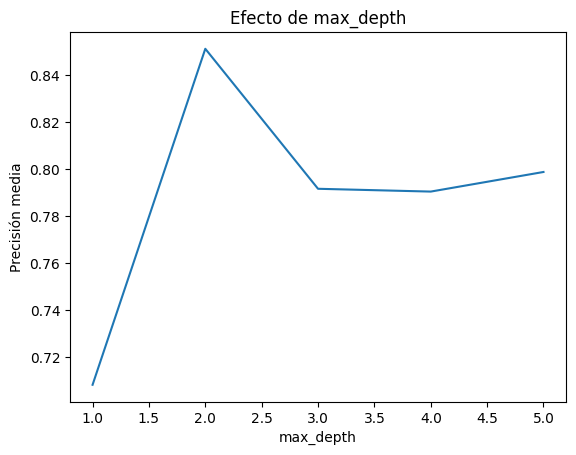

In [6]:
# Graficar resultados
df_results = pd.DataFrame(resultados)

#Visualización del efecto individual de cada hiperparámetro en la precisión

#Efecto de max_depth
depth_analysis = (
    df_results
    .groupby("max_depth")["precision"]
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(depth_analysis["max_depth"], depth_analysis["precision"])
plt.xlabel("max_depth")
plt.ylabel("Precisión media")
plt.title("Efecto de max_depth")
plt.show()


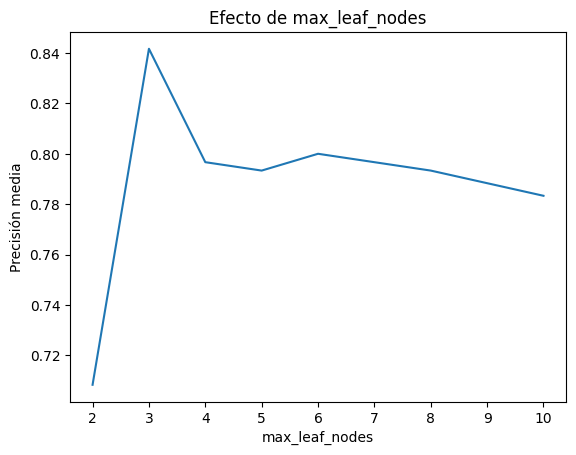

In [7]:
#Efecto de max_leaf_nodes
leaf_nodes_analysis = (
    df_results
    .groupby("max_leaf_nodes")["precision"]
    .mean()
    .reset_index()
)
plt.figure()
plt.plot(leaf_nodes_analysis["max_leaf_nodes"], leaf_nodes_analysis["precision"])
plt.xlabel("max_leaf_nodes")
plt.ylabel("Precisión media")
plt.title("Efecto de max_leaf_nodes")
plt.show()

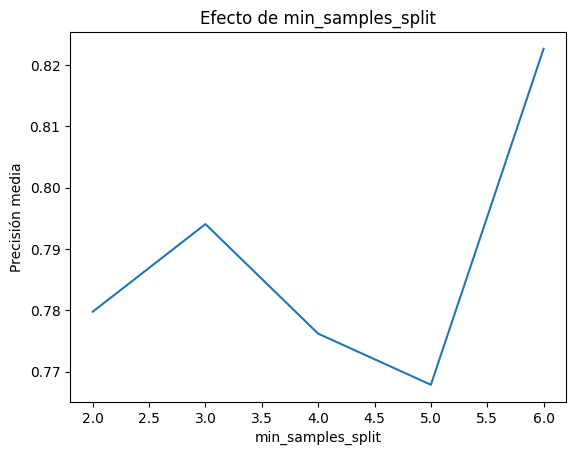

In [8]:
#Efecto de min_samples_split
min_samples_split_analysis = (
    df_results
    .groupby("min_samples_split")["precision"]
    .mean()
    .reset_index()
)
plt.figure()
plt.plot(min_samples_split_analysis["min_samples_split"], min_samples_split_analysis["precision"])
plt.xlabel("min_samples_split")
plt.ylabel("Precisión media")
plt.title("Efecto de min_samples_split")
plt.show()


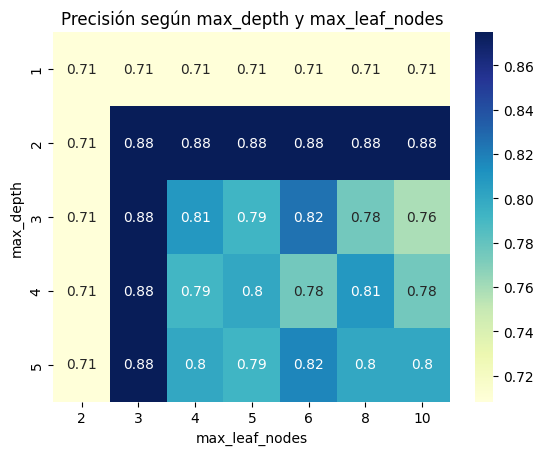

In [9]:
#Interacción entre varios parámetros

#Max_depth y max_leaf_nodes
pivot_table = df_results.pivot_table(
    values="precision",
    index="max_depth",
    columns="max_leaf_nodes",
    aggfunc="mean"
)

plt.figure()
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Precisión según max_depth y max_leaf_nodes")
plt.show()

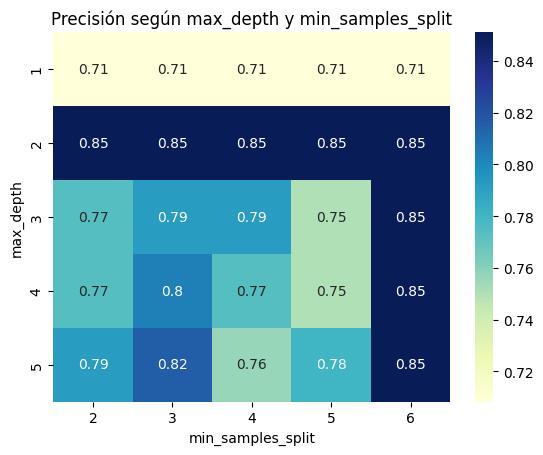

In [10]:
#Max_depth y min_samples_split
pivot_table = df_results.pivot_table(
    values="precision",
    index="max_depth",
    columns="min_samples_split",
    aggfunc="mean"
)
plt.figure()
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Precisión según max_depth y min_samples_split")
plt.show()

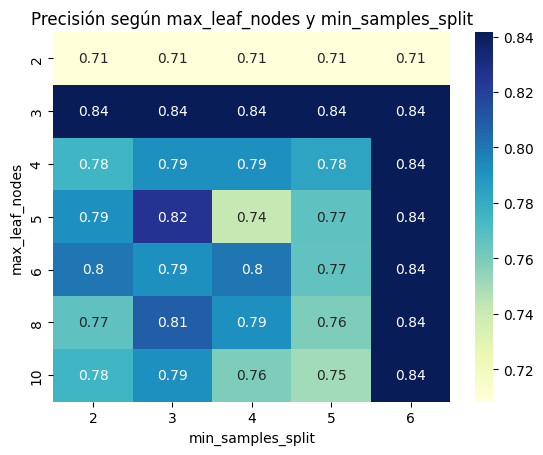

In [11]:
#Max_leaf_nodes y min_samples_split
pivot_table = df_results.pivot_table(
    values="precision",
    index="max_leaf_nodes",
    columns="min_samples_split",
    aggfunc="mean"
)
plt.figure()
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Precisión según max_leaf_nodes y min_samples_split")
plt.show()

Habrá que explicarlo tal pero hay valores óptimos muy claros: de entre los óptimos se escoge el más simple

##### Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=6, Precisión: 0.8750

In [16]:
df_figura = pd.read_csv('data/lenses.csv')
X,y = preprocesado(df_figura)
dt = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=3, max_depth=3, min_samples_split=6)
dt.fit(X, y)
#Convertir X a dataframe para obtener los nombres de las columnas
features = ["age_young", "age_pre-presbyopic", "age_presbyopic", "prescription_myope", "prescription_hypermetrope", "astigmatic_no", "astigmatic_yes", "tear_rate_reduced", "tear_rate_normal"]
X_df = pd.DataFrame(X, columns=features)
text_representation = tree.export_text(
dt, feature_names=list(X_df.columns), class_names=["no lenses", "soft", "hard"])
print(text_representation)

Características (X):
   Age_0  Age_1  Age_2  Prescription_0  Prescription_1  Astigmatic_0  \
0   True  False  False            True           False          True   
1   True  False  False            True           False          True   
2   True  False  False            True           False         False   
3   True  False  False            True           False         False   
4   True  False  False           False            True          True   

   Astigmatic_1  TearRate_0  TearRate_1  
0         False        True       False  
1         False       False        True  
2          True        True       False  
3          True       False        True  
4         False        True       False  
|--- tear_rate_reduced <= 0.50
|   |--- astigmatic_yes <= 0.50
|   |   |--- class: soft
|   |--- astigmatic_yes >  0.50
|   |   |--- class: hard
|--- tear_rate_reduced >  0.50
|   |--- class: no lenses

